In [ ]:
Part A — Data Preparation

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
trades = pd.read_csv("historical_data.csv")
fg     = pd.read_csv("fear_greed_index.csv")

In [31]:
print("Trades — Rows:", trades.shape[0], "| Columns:", trades.shape[1])
print("Fear/Greed — Rows:", fg.shape[0], "| Columns:", fg.shape[1])

trades.info()

Trades — Rows: 211224 | Columns: 16
Fear/Greed — Rows: 2644 | Columns: 4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64


In [32]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [33]:
fg.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [34]:
print("Duplicate rows in trades:", trades.duplicated().sum())
print("Duplicate rows in fg:    ", fg.duplicated().sum())

Duplicate rows in trades: 0
Duplicate rows in fg:     0


In [35]:
trades['Date'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True).dt.normalize()

fg['date'] = pd.to_datetime(fg['date'])

merged = trades.merge(
    fg[['date', 'value', 'classification']],
    left_on='Date', right_on='date',
    how='left'
)

print("Merged rows:", len(merged))
print("Unmatched (no sentiment):", merged['classification'].isnull().sum())

Merged rows: 211224
Unmatched (no sentiment): 6


In [36]:
def broad_sentiment(s):
    if 'Fear'  in str(s): return 'Fear'
    if 'Greed' in str(s): return 'Greed'
    return 'Neutral'

merged['Sentiment'] = merged['classification'].apply(broad_sentiment)

merged['Sentiment'].value_counts()

Sentiment
Greed      90295
Fear       83237
Neutral    37692
Name: count, dtype: int64

In [37]:
daily_pnl = (
    merged
    .groupby(['Date', 'Account', 'Sentiment'])['Closed PnL']
    .sum()
    .reset_index()
)

daily_pnl.head(10)

,Date,Account,Sentiment,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000
5,2023-12-17,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,304.982785
6,2023-12-18,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000
7,2023-12-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,1000.538612
8,2023-12-20,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,162.732282
9,2023-12-21,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,537.211402


In [38]:
closes = merged[merged['Closed PnL'] != 0].copy()

closes['Win'] = np.where(closes['Closed PnL'] > 0, 1, 0)

win_rate = (
    closes
    .groupby('Account')['Win']
    .mean()
    .reset_index()
    .rename(columns={'Win': 'Win Rate'})
)

win_rate.round(3)

,Account,Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.793
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.774
2,0x271b280974205ca63b716753467d5a371de622ab,0.716
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.862
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.817
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.651
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,0.666
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,1.000
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.000
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1.000


In [39]:
avg_size = (
    trades
    .groupby('Account')['Size USD']
    .mean()
    .reset_index()
    .rename(columns={'Size USD': 'Avg Trade Size USD'})
)

avg_size.round(2)

,Account,Avg Trade Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.58
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.23
2,0x271b280974205ca63b716753467d5a371de622ab,8893.00
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.63
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.89
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1729.94
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,4790.58
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,3445.47
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,5189.37
9,0x430f09841d65beb3f27765503d0f850b8bce7713,2397.82


In [41]:
trades_per_day = (
    merged
    .groupby(['Date', 'Account'])
    .size()
    .reset_index(name='Num Trades')
)

trades_per_day.head()

,Date,Account,Num Trades
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,9
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,11
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,3


In [42]:
longs  = trades[trades['Direction'] == 'Open Long'].groupby('Account').size()
shorts = trades[trades['Direction'] == 'Open Short'].groupby('Account').size()

ls_ratio = (longs / (shorts + 1e-9)).reset_index()
ls_ratio.columns = ['Account', 'Long Short Ratio']
ls_ratio['Long Short Ratio'] = ls_ratio['Long Short Ratio'].round(2)

ls_ratio

,Account,Long Short Ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.15
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.95
2,0x271b280974205ca63b716753467d5a371de622ab,0.03
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.40
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1178.00
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.10
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,0.17
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,NaN
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,0.00
9,0x430f09841d65beb3f27765503d0f850b8bce7713,0.66


In [ ]:
Part B — Analysis

In [43]:
pnl_by_sentiment = (
    merged
    .groupby('Sentiment')['Closed PnL']
    .mean()
    .reindex(['Fear', 'Neutral', 'Greed'])
    .reset_index()
    .rename(columns={'Closed PnL': 'Avg PnL per Trade'})
)

print(pnl_by_sentiment.round(2))

  Sentiment  Avg PnL per Trade
0      Fear              49.21
1   Neutral              35.43
2     Greed              53.88


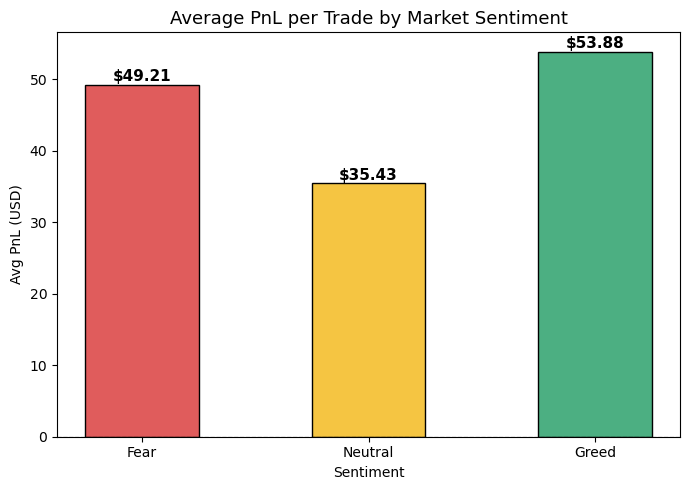

In [55]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#e05c5c', '#f5c542', '#4caf82']
bars = ax.bar(
    pnl_by_sentiment['Sentiment'],
    pnl_by_sentiment['Avg PnL per Trade'],
    color=colors, edgecolor='black', width=0.5
)

# Add value labels on bars
for bar, val in zip(bars, pnl_by_sentiment['Avg PnL per Trade']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'${val:.2f}',
        ha='center', fontsize=11, fontweight='bold'
    )

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Average PnL per Trade by Market Sentiment', fontsize=13)
ax.set_ylabel('Avg PnL (USD)')
ax.set_xlabel('Sentiment')
plt.tight_layout()
plt.savefig('chart1_pnl_by_sentiment.png', dpi=150)
plt.show()

In [45]:
wr_by_sentiment = (
    closes
    .groupby('Sentiment')['Win']
    .mean()
    .reindex(['Fear', 'Neutral', 'Greed'])
    .reset_index()
    .rename(columns={'Win': 'Win Rate'})
)

print(wr_by_sentiment.round(3))

  Sentiment  Win Rate
0      Fear     0.844
1   Neutral     0.824
2     Greed     0.825


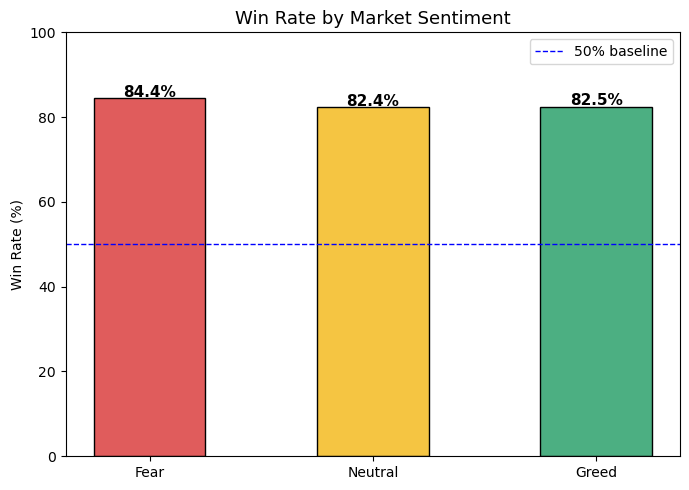

In [46]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    wr_by_sentiment['Sentiment'],
    wr_by_sentiment['Win Rate'] * 100,
    color=colors, edgecolor='black', width=0.5
)

for bar, val in zip(bars, wr_by_sentiment['Win Rate'] * 100):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', fontsize=11, fontweight='bold'
    )

ax.axhline(50, color='blue', linewidth=1, linestyle='--', label='50% baseline')
ax.set_title('Win Rate by Market Sentiment', fontsize=13)
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig('chart2_winrate_by_sentiment.png', dpi=150)
plt.show()

In [47]:
freq_by_sentiment = (
    merged
    .groupby(['Date', 'Sentiment'])
    .size()
    .reset_index(name='Num Trades')
    .groupby('Sentiment')['Num Trades']
    .mean()
    .reindex(['Fear', 'Neutral', 'Greed'])
    .reset_index()
    .rename(columns={'Num Trades': 'Avg Trades per Day'})
)

print(freq_by_sentiment.round(1))

  Sentiment  Avg Trades per Day
0      Fear               792.7
1   Neutral               554.3
2     Greed               294.1


In [48]:
size_by_sentiment = (
    merged
    .groupby('Sentiment')['Size USD']
    .mean()
    .reindex(['Fear', 'Neutral', 'Greed'])
    .reset_index()
    .rename(columns={'Size USD': 'Avg Position Size USD'})
)

print(size_by_sentiment.round(2))

  Sentiment  Avg Position Size USD
0      Fear                7182.01
1   Neutral                4784.32
2     Greed                4574.42


In [49]:
longs_sent  = merged[merged['Direction'] == 'Open Long'].groupby('Sentiment').size()
shorts_sent = merged[merged['Direction'] == 'Open Short'].groupby('Sentiment').size()

bias = pd.DataFrame({
    'Longs':  longs_sent,
    'Shorts': shorts_sent
}).reindex(['Fear', 'Neutral', 'Greed']).fillna(0)

bias['L/S Ratio'] = (bias['Longs'] / (bias['Shorts'] + 1e-9)).round(3)
print(bias)

           Longs  Shorts  L/S Ratio
Sentiment                          
Fear       24829   14061      1.766
Neutral    10222    6353      1.609
Greed      14844   19327      0.768


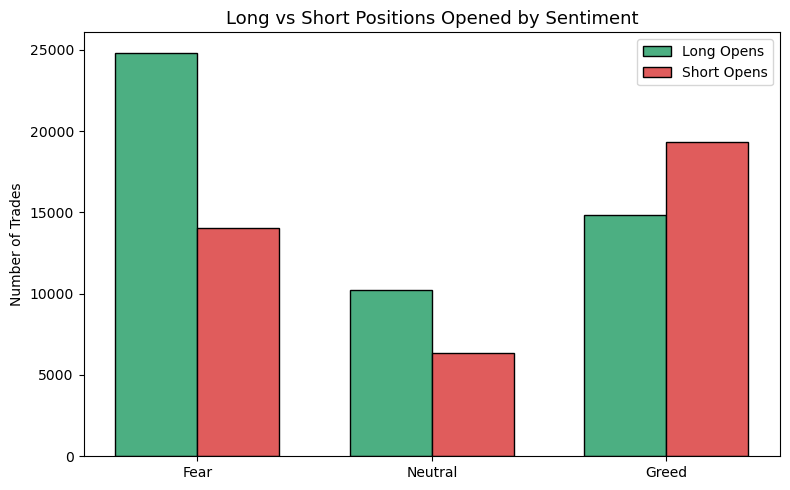

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(3)
w = 0.35
ax.bar(x - w/2, bias['Longs'],  width=w, label='Long Opens',  color='#4caf82', edgecolor='black')
ax.bar(x + w/2, bias['Shorts'], width=w, label='Short Opens', color='#e05c5c', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(['Fear', 'Neutral', 'Greed'])
ax.set_title('Long vs Short Positions Opened by Sentiment', fontsize=13)
ax.set_ylabel('Number of Trades')
ax.legend()
plt.tight_layout()
plt.savefig('chart3_long_short_bias.png', dpi=150)
plt.show()

In [51]:
# Build one summary row per trader
trader_summary = closes.groupby('Account').agg(
    Total_PnL   = ('Closed PnL', 'sum'),
    Win_Rate    = ('Win',        'mean'),
    Num_Trades  = ('Trade ID',   'count'),
).reset_index()

# Add avg trade size
trader_summary = trader_summary.merge(avg_size, on='Account', how='left')

# Segment 1: High vs Low frequency
median_trades = trader_summary['Num_Trades'].median()
trader_summary['Frequency'] = np.where(
    trader_summary['Num_Trades'] > median_trades,
    'Frequent', 'Infrequent'
)

# Segment 2: Winner / Loser / Inconsistent
def label_trader(row):
    if row['Win_Rate'] >= 0.85 and row['Total_PnL'] > 0:
        return 'Consistent Winner'
    elif row['Total_PnL'] < 0:
        return 'Consistent Loser'
    else:
        return 'Inconsistent'

trader_summary['Performance'] = trader_summary.apply(label_trader, axis=1)

print(trader_summary[['Account','Total_PnL','Win_Rate','Num_Trades',
                        'Frequency','Performance']].round(3))

                                       Account    Total_PnL  Win_Rate  \
0   0x083384f897ee0f19899168e3b1bec365f52a9012  1600229.820     0.793   
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    47885.321     0.774   
2   0x271b280974205ca63b716753467d5a371de622ab   -70436.191     0.716   
3   0x28736f43f1e871e6aa8b1148d38d4994275d72c4   132464.815     0.862   
4   0x2c229d22b100a7beb69122eed721cee9b24011dd   168658.005     0.817   
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891   -31203.600     0.651   
6   0x39cef799f8b69da1995852eea189df24eb5cae3c    14456.919     0.666   
7   0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    53496.247     1.000   
8   0x420ab45e0bd8863569a5efbb9c05d91f40624641   199505.593     1.000   
9   0x430f09841d65beb3f27765503d0f850b8bce7713   416541.872     1.000   
10  0x47add9a56df66b524d5e2c1993a43cde53b6ed85   103343.716     0.822   
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4   677747.051     0.948   
12  0x4f93fead39b70a1824f981a54d4e55b278e9f760   30

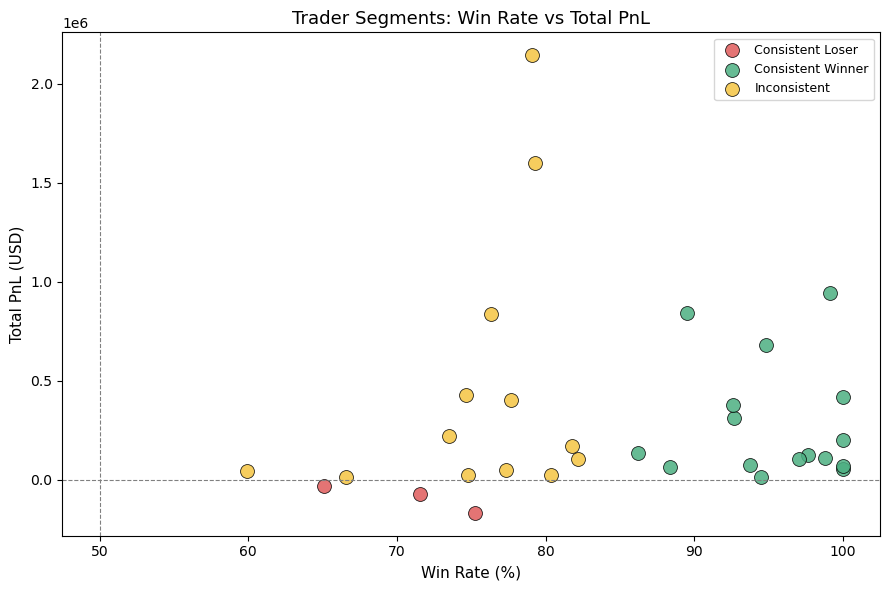

In [52]:
seg_colors = {
    'Consistent Winner': '#4caf82',
    'Consistent Loser':  '#e05c5c',
    'Inconsistent':      '#f5c542'
}

fig, ax = plt.subplots(figsize=(9, 6))

for seg, grp in trader_summary.groupby('Performance'):
    ax.scatter(
        grp['Win_Rate'] * 100,
        grp['Total_PnL'],
        label=seg,
        color=seg_colors[seg],
        s=100, edgecolors='black', linewidth=0.6, alpha=0.85
    )

ax.axhline(0,  color='gray', linestyle='--', linewidth=0.8)
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Win Rate (%)', fontsize=11)
ax.set_ylabel('Total PnL (USD)', fontsize=11)
ax.set_title('Trader Segments: Win Rate vs Total PnL', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('chart4_segments.png', dpi=150)
plt.show()

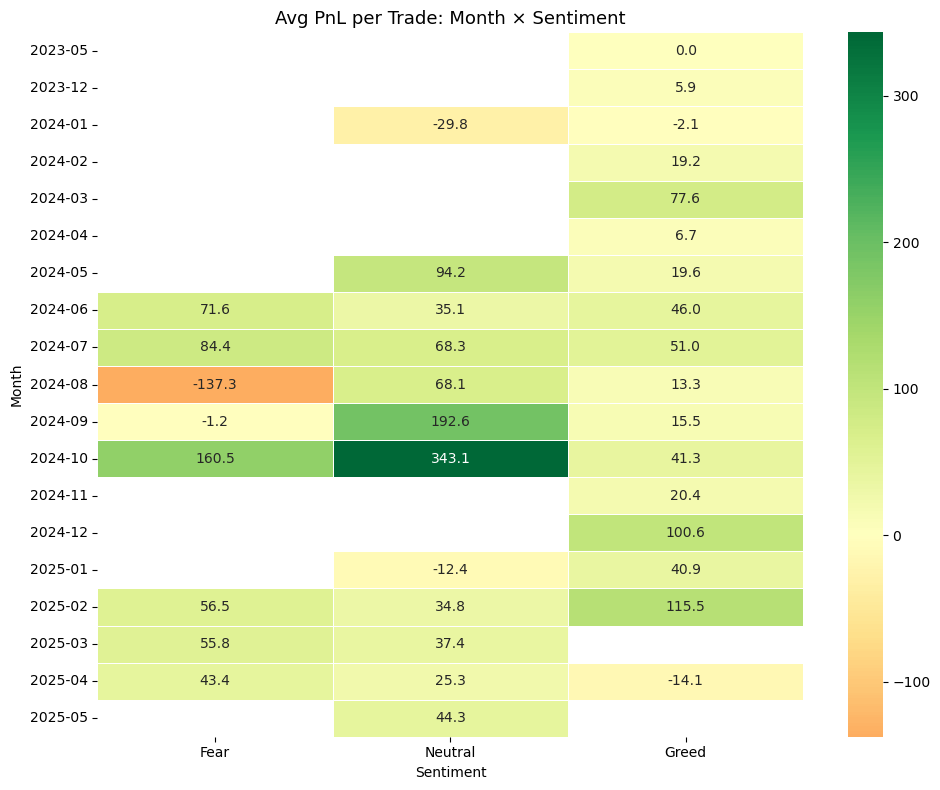

In [53]:
# PnL by month and sentiment — shows seasonality
merged['Month'] = merged['Date'].dt.to_period('M').astype(str)

monthly_pnl = (
    merged
    .groupby(['Month', 'Sentiment'])['Closed PnL']
    .mean()
    .unstack()
    [['Fear', 'Neutral', 'Greed']]
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    monthly_pnl,
    annot=True, fmt='.1f',
    cmap='RdYlGn', center=0,
    linewidths=0.4, linecolor='white',
    ax=ax
)

ax.set_title('Avg PnL per Trade: Month × Sentiment', fontsize=13)
ax.set_xlabel('Sentiment')
ax.set_ylabel('Month')
plt.tight_layout()
plt.savefig('chart5_heatmap.png', dpi=150)
plt.show()

Part C - Strategy Recommendations

1. Greed days had the highest avg PnL per trade ($53.88) but Fear days had the highest win rate (84.4% vs 82.5%)
2. On Fear days traders opened ~25,000 longs vs 14,000 shorts. On Greed days it flipped - more shorts (19,500) than longs (15,000)
3. High win-rate doesn't always mean high total PnL — the scatter plot shows several "Inconsistent" traders made $1.5M–$2.1M despite 
   not being in the Consistent Winner group, meaning a few large bets drove their returns

Strategy 1 - Long on Fear, Short on Greed
Fear days = 84.4% win rate + 1.77x more longs than shorts already working.
Simple rule: FG index < 45 → go long. FG index > 55 → reduce longs, lean short.

Strategy 2 - Greed days: trade less, not more
Greed has highest avg PnL ($53.88) but lowest win rate (82.5%) - that means fewer wins but bigger size. Risky pattern.
Simple rule: On Greed days, cut position size by 30-40%. Don't overtrade just because market feels good.